## Clustering & Segmentation

##### Dimensionality Reduction yielded to potential inputs: PCA and UMAP
##### PCA will be used for clustering, particularly K-Means
> ##### PCA removes multicollinearity and noise
> ##### We also know which PCs relate to treatment from previous exercise
##### UMAP will be used for visualization
> ##### Simple 2D space for easy interpretation

### Load relevant libraries

In [33]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

### Read in the Data

In [3]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/OSMH/Data'
os.chdir(path)

In [4]:
df = pd.read_csv('full_data.csv')

### Number of Clusters

In [6]:
### Define variables
pc_cols = [f'PC{i}' for i in range (1,11)]
X_cluster = df[pc_cols]

inertia = []
silhouette = []

K_range = range(2,11)

for k in K_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_cluster, labels))

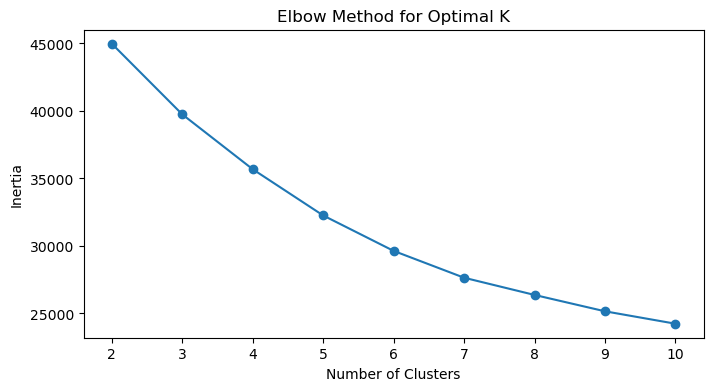

In [14]:
### Elbow Plot
plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

##### Rate of improvement slows around K=3 and K=4

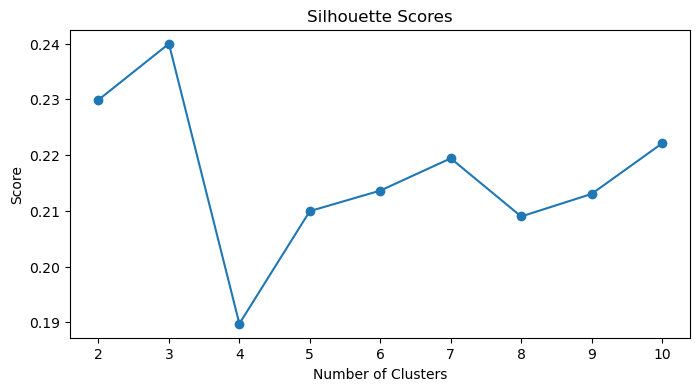

In [17]:
### Silhouette Plot
plt.figure(figsize=(8,4))
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

##### Silhouette is a measure of separation
> ##### <0.2 is weak
> ##### 0.2-0.3 is moderate
> ##### 0.3+ is strong
##### K=3 shows the highest amount of separation
> ##### K=2, 10, and 7 are other options

##### Given elbow and silhouette results, K=3 is the best choice for number of clusters
> ##### Near the elbow, highest silhouette
> ##### Also provides simpler interpretation and easier segmentation story

### Clustering

In [22]:
### Fit the model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(df[pc_cols])

##### Several variables are ternary encoded, with 2's representing 'I don't know' responses
##### Earlier analysis showed that 2's were a relatively low portion of responses for most variables, so there was no need for filtering when it came to dimensionality reduction or clustering
##### However, in interpreting the cluster segmentation, their inclusion may artifically inflate results
> ##### In practice, this might present as higher workplace support for a cluster, but may actually represent a population uninformed about their options

In [49]:
### Cluster medians for remaining variables to determine uncertainty in responses
df.groupby('cluster')[[
'support_score',
'work_interfere_enc',
'family_history_enc',
'mental_vs_physical_enc',
'leave_enc',
'obs_consequence_enc',
'treatment_enc',
'wellness_program_enc',
'care_options_enc',
'seek_help_enc',
'benefits_enc'
]].median()

,support_score,work_interfere_enc,family_history_enc,mental_vs_physical_enc,leave_enc,obs_consequence_enc,treatment_enc,wellness_program_enc,care_options_enc,seek_help_enc,benefits_enc
cluster,,,,,,,,,,,
0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,2.0,1.0,2.0,1.0,0.0,1.0,2.0,2.0,2.0,2.0
2,1.0,2.0,1.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0


##### Cluster 1 medians show that '2' responses dominate. It may be worth analyzing group means with these responses excluded

In [55]:
# List of ternary columns
ternary_cols = [
    'family_history_enc', 'benefits_enc', 'care_options_enc', 
    'wellness_program_enc', 'seek_help_enc', 'anonymity_enc',
    'mental_vs_physical_enc'
]

# Copy df for calculation
df_clusters_clean = df.copy()

# Replace 2s with NaN for descriptive calculations
df_clusters_clean[ternary_cols] = df_clusters_clean[ternary_cols].replace(2, np.nan)

# Calculate cluster-level means, ignoring NaNs
cluster_means_clean = df_clusters_clean.groupby('cluster')[[
    'support_score', 'work_interfere_enc', 'family_history_enc',
    'mental_vs_physical_enc', 'leave_enc', 'obs_consequence_enc',
    'treatment_enc', 'wellness_program_enc', 'care_options_enc',
    'seek_help_enc', 'benefits_enc'
]].mean()

cluster_means_clean

,support_score,work_interfere_enc,family_history_enc,mental_vs_physical_enc,leave_enc,obs_consequence_enc,treatment_enc,wellness_program_enc,care_options_enc,seek_help_enc,benefits_enc
cluster,,,,,,,,,,,
0,0.944643,1.461698,0.410714,0.319018,1.922438,0.322581,0.528571,0.197318,0.495763,0.231760,0.424779
1,0.027536,2.254545,0.503636,0.909091,0.942308,0.012500,0.560870,0.222222,0.500000,0.666667,0.823529
2,1.011380,2.162615,0.533192,0.987097,1.482925,0.000000,0.567552,0.284339,0.461858,0.389837,0.733910


##### Previous PCA results showed strong loadings from the following variables:
> ##### work_interfere, family_history, mental_vs_physical, support_score, leave, obs_consequence
##### These variables explain large parts of the dataset structure and will be our explanatory variables in analyzing clusters

In [56]:
### Cluster medians for remaining variables to determine uncertainty in responses
df.groupby('cluster')[[
'support_score',
'work_interfere_enc',
'family_history_enc',
'mental_vs_physical_enc',
'leave_enc',
'obs_consequence_enc',
'treatment_enc',
'wellness_program_enc',
'care_options_enc',
'seek_help_enc',
'benefits_enc'
]].mean()

,support_score,work_interfere_enc,family_history_enc,mental_vs_physical_enc,leave_enc,obs_consequence_enc,treatment_enc,wellness_program_enc,care_options_enc,seek_help_enc,benefits_enc
cluster,,,,,,,,,,,
0,0.944643,1.461698,0.410714,0.532143,1.922438,0.322581,0.528571,0.319643,0.732143,0.528571,0.728571
1,0.027536,2.254545,0.807246,1.947826,0.942308,0.012500,0.560870,1.976812,1.986957,1.976812,1.971014
2,1.011380,2.162615,0.787861,1.954187,1.482925,0.000000,0.567552,0.440035,0.811497,0.816458,1.316895


##### Removing '2' responses from means impacts the following variables:
> ##### family_history, mental_vs_physical, wellness_program, care_options, seek_help, benefits
##### However, results are inflated across all clusters and trends continue to hold when removed

In [30]:
df['cluster'].value_counts(normalize=True)

cluster
2    0.732735
1    0.147530
0    0.119735
Name: proportion, dtype: float64

##### Cluster 0 (12%)
> ##### Lowest scores for work inteference, family history, and stigma perception, as well as lowest treatment rate
> ##### High support score
> ##### Highest score for observed consequences
##### Less severe mental health impact and less personal risk exposure; may simply need treatment less often
##### Label: Low-Risk / Low-Support Respondents
> ##### Lower treatment rates likely due to lower need, not stigma or lack of support

##### Cluster 1 (15%)
> ##### Highest scores for work inteference, family history, and observed consequences
> ##### High scores for stigma perception and treatment rate
> ##### Lowest support score (by far)
##### High mental health impact, but work in enviromnments with little support infrastructure
##### Treatment rate still high, so may be seeking treatment despite workplace barriers
##### Label: High-Risk / Unsupported (or Uninformed) Workers
> ##### This may be the most vulnerable segment in the dataset

##### Cluster 2 (73%)
> ##### Highest support score, as well as highest treatment rate
> ##### High scores for work inteference, family history, and stigma perception
> ##### Lowest score for observed consequences (0)
##### Similar severity to Cluster 1, but have stronger support structures
##### Label: High-Risk / Supported Workers
> ##### Demonstrates potential impact of workplace support resources

##### Interesting Insights:
> ##### Clusters 1 & 2 have similar treatment rates, so workplace support may not drastically change propensity among people with high mental health impact
> > ##### However, support may still affect how safe or easy seeking treatment feels for those who need it
> ##### Cluster 0 reports far more observed workplace consequences
> > ##### Those with less personal mental health exposure may be more sensitive to observing consequences affecting others
> ##### Positive sign that the largest group (Cluster 2) shows a high level of workplace support
> ##### However, negative sign that ~88% of respondents show high-risk for mental health
> > ##### Possible bias in respondents: those with higher mental health impact may be more likely to respond to mental health surveys

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

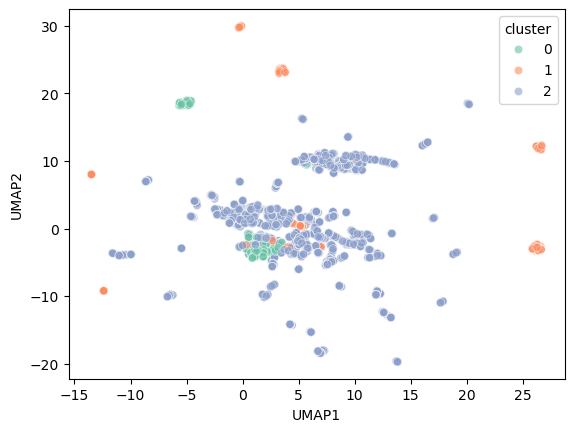

In [32]:
##### UMAP by Clusters
sns.scatterplot(
    data=df,
    x='UMAP1',
    y='UMAP2',
    hue='cluster',
    palette='Set2',
    alpha=0.6
)

<Axes: xlabel='cluster', ylabel='treatment_enc'>

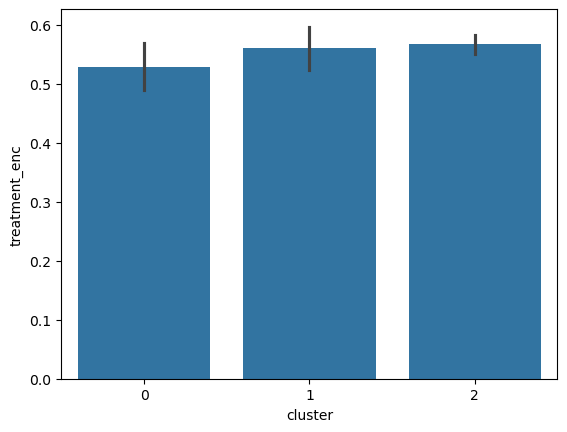

In [31]:
### Treatment seeking by Cluster
sns.barplot(
    data=df,
    x='cluster',
    y='treatment_enc'
)

### ANOVA

##### Analysis of Variance can be used to quantify which original variables most strongly differentiate the clusters

In [42]:
anova_results = []

feature_cols = [
    'support_score',
    'work_interfere_enc',
    'family_history_enc',
    'mental_vs_physical_enc',
    'obs_consequence_enc',
    'leave_enc',
    'seek_help_enc',
    'anonymity_enc',
    'benefits_enc',
    'care_options_enc',
    'wellness_program_enc'
]

for col in feature_cols:

    group0 = df[df['cluster']==0][col].dropna()
    group1 = df[df['cluster']==1][col].dropna()
    group2 = df[df['cluster']==2][col].dropna()

    f_stat, p_val = f_oneway(group0, group1, group2)

    anova_results.append({
        'feature': col,
        'F_stat': f_stat,
        'p_value': p_val
    })

anova_df = pd.DataFrame(anova_results).sort_values('F_stat', ascending=False)

anova_df

,feature,F_stat,p_value
3,mental_vs_physical_enc,4893.631582,0.000000e+00
10,wellness_program_enc,1968.655473,0.000000e+00
9,care_options_enc,815.219078,1.944913e-304
6,seek_help_enc,774.159154,3.946056e-291
8,benefits_enc,546.441843,5.532797e-214
0,support_score,302.180602,3.820319e-124
7,anonymity_enc,169.865373,6.112752e-72
4,obs_consequence_enc,161.880547,3.109595e-63
1,work_interfere_enc,114.624532,8.652432e-48
2,family_history_enc,73.152521,5.216169e-32


##### The strongest separator of clusters is whether respondents believe mental health is treated the same as physical health
> ##### This is potentially what drives the separation between CLuster 0 and Clusters 1/2
##### Workplace policy / support encapsulate the other top drivers
> ##### This may be what separates Cluster 1 from Cluster 2
##### Family history is significant, but much weaker
##### All variables have statistical significance

### Save data for Propensity Modeling

In [58]:
df.to_csv('clustered_data.csv', index=False)